SOAL 1: PROBLEM DEFINITION & DATA ACQUISITION

# Prediksi Jejak Karbon Kendaraan

Nama: Delvia Mareta Dealova

NIM: A11.2024.15658

---

A. Latar Belakang Masalah

Sektor transportasi merupakan salah satu kontributor terbesar emisi gas rumah kaca secara global. Pemilihan kendaraan yang kurang efisien berdampak langsung pada akselerasi krisis iklim. Melalui pembelajaran mesin, proyek ini memprediksi emisi CO2 (g/km) berdasarkan spesifikasi mesin kendaraan untuk membantu transparansi informasi bagi konsumen.

---

B. Tujuan Analisis

Membangun model regresi prediktif untuk mengestimasi emisi karbon kendaraan berdasarkan fitur teknisnya secara akurat.

---

C. Metrik Kesuksesan Proyek

- R² Score >= 0.90
- Nilai MAE dan RMSE seminimal mungkin.

Import Libraries Awal

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set tema visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("✓ Libraries berhasil dimuat!")

✓ Libraries berhasil dimuat!


Data Acquisition & Info Awal

In [4]:
# Membaca dataset dari folder lokal 
path_dataset = '../data/raw/CO2 Emissions_Canada.csv'
df = pd.read_csv(path_dataset)

print(f"✓ Dataset berhasil dimuat! Ukuran: {df.shape[0]} baris, {df.shape[1]} kolom\n")
print("="*40 + "\nINFORMASI FITUR (df.info())\n" + "="*40)
print(df.info())

✓ Dataset berhasil dimuat! Ukuran: 7385 baris, 12 kolom

INFORMASI FITUR (df.info())
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null

Statistik Deskriptif Awal

In [5]:
print("="*40 + "\nSTATISTIK DESKRIPTIF FITUR NUMERIK\n" + "="*40)
print(df.describe().T)

print("\n" + "="*40 + "\nSTATISTIK DESKRIPTIF FITUR KATEGORIKAL\n" + "="*40)
print(df.describe(include=['object']).T)

STATISTIK DESKRIPTIF FITUR NUMERIK
                                   count        mean        std   min    25%  \
Engine Size(L)                    7385.0    3.160068   1.354170   0.9    2.0   
Cylinders                         7385.0    5.615030   1.828307   3.0    4.0   
Fuel Consumption City (L/100 km)  7385.0   12.556534   3.500274   4.2   10.1   
Fuel Consumption Hwy (L/100 km)   7385.0    9.041706   2.224456   4.0    7.5   
Fuel Consumption Comb (L/100 km)  7385.0   10.975071   2.892506   4.1    8.9   
Fuel Consumption Comb (mpg)       7385.0   27.481652   7.231879  11.0   22.0   
CO2 Emissions(g/km)               7385.0  250.584699  58.512679  96.0  208.0   

                                    50%    75%    max  
Engine Size(L)                      3.0    3.7    8.4  
Cylinders                           6.0    6.0   16.0  
Fuel Consumption City (L/100 km)   12.1   14.6   30.6  
Fuel Consumption Hwy (L/100 km)     8.7   10.2   20.6  
Fuel Consumption Comb (L/100 km)   10.6   12

SOAL 2: EXPLORATORY DATA ANALYSIS & PREPROCESSING

Analisis Kualitas Data & Handling Duplikat

In [6]:
# Cek missing values
print(f"Jumlah Missing Values:\n{df.isnull().sum()}\n")

# Cek & Hapus Duplikat
print(f"Jumlah Baris Duplikat Awal: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Jumlah Baris Setelah Duplikat Dihapus: {df.shape[0]}")

Jumlah Missing Values:
Make                                0
Model                               0
Vehicle Class                       0
Engine Size(L)                      0
Cylinders                           0
Transmission                        0
Fuel Type                           0
Fuel Consumption City (L/100 km)    0
Fuel Consumption Hwy (L/100 km)     0
Fuel Consumption Comb (L/100 km)    0
Fuel Consumption Comb (mpg)         0
CO2 Emissions(g/km)                 0
dtype: int64

Jumlah Baris Duplikat Awal: 1103
Jumlah Baris Setelah Duplikat Dihapus: 6282


Visualisasi Insight 1 - 3

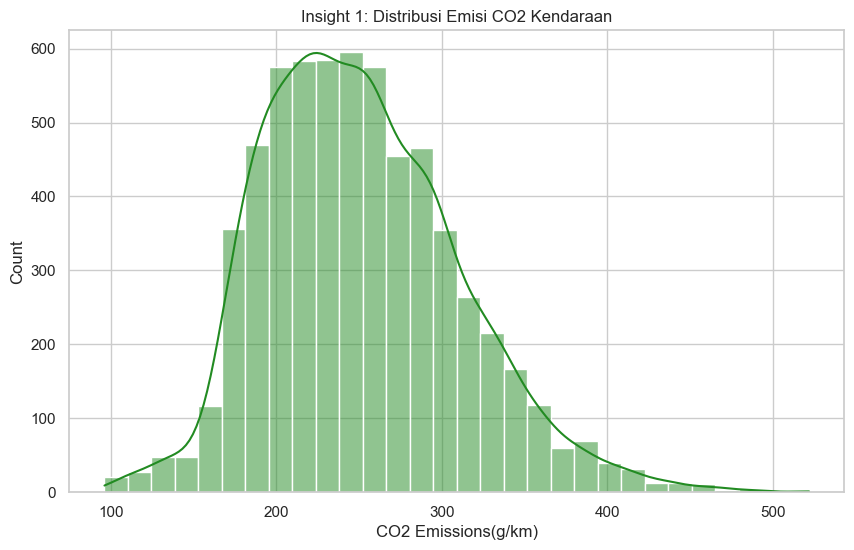

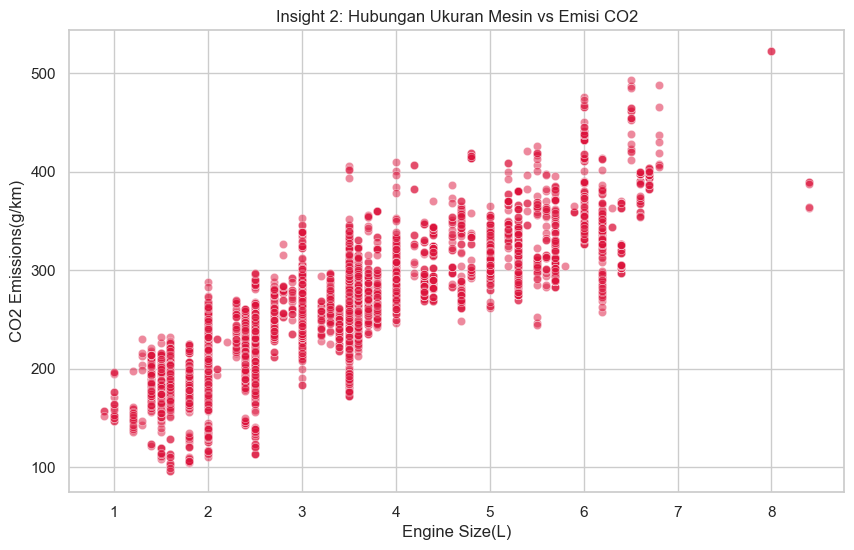

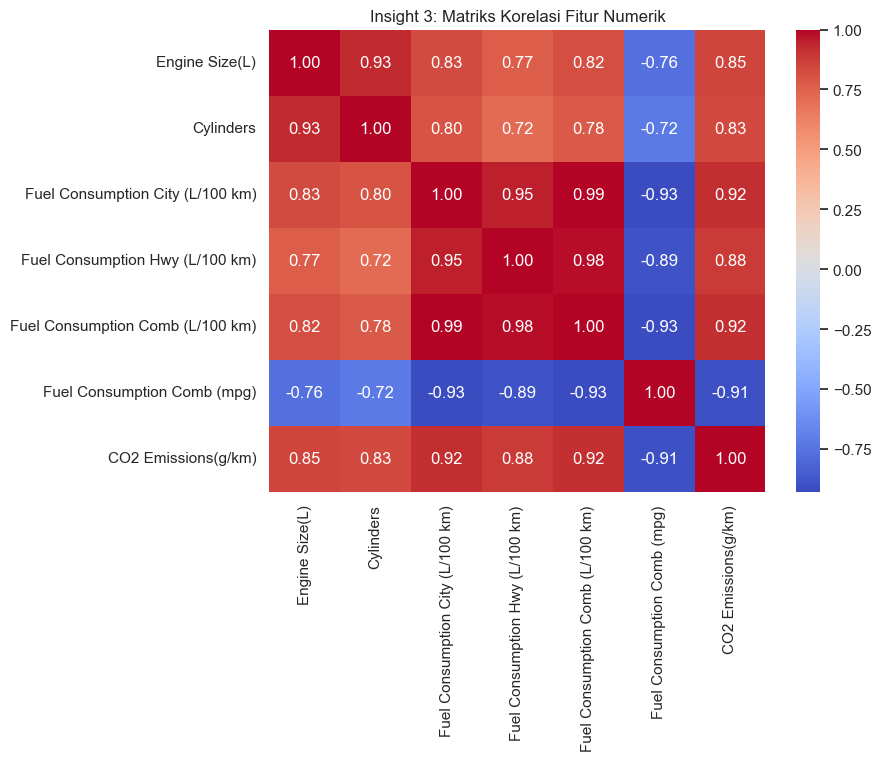

In [7]:
os.makedirs('../reports', exist_ok=True)

# 1. Distribusi Target
plt.figure()
sns.histplot(df['CO2 Emissions(g/km)'], kde=True, color='forestgreen', bins=30)
plt.title('Insight 1: Distribusi Emisi CO2 Kendaraan')
plt.savefig('../reports/insight1_dist.png')
plt.show()

# 2. Scatter Plot Engine Size vs CO2
plt.figure()
sns.scatterplot(x='Engine Size(L)', y='CO2 Emissions(g/km)', data=df, alpha=0.5, color='crimson')
plt.title('Insight 2: Hubungan Ukuran Mesin vs Emisi CO2')
plt.savefig('../reports/insight2_scatter.png')
plt.show()

# 3. Heatmap Korelasi
plt.figure(figsize=(8, 6))
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Insight 3: Matriks Korelasi Fitur Numerik')
plt.savefig('../reports/insight3_heatmap.png')
plt.show()

Visualisasi Insight 4 - 5

C:\Users\Delvia Mareta\AppData\Local\Temp\ipykernel_14532\1092870060.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Fuel Type', y='CO2 Emissions(g/km)', data=df, palette='viridis', order=fuel_order, errorbar=None)


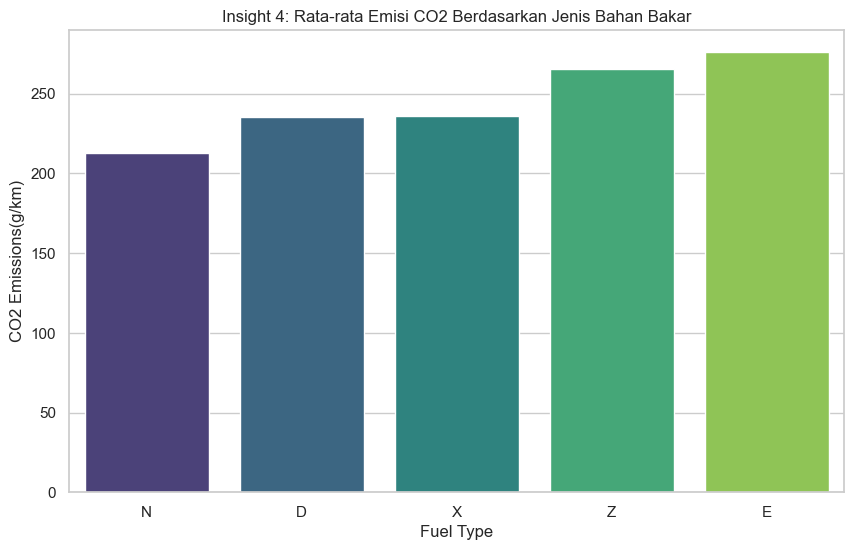

C:\Users\Delvia Mareta\AppData\Local\Temp\ipykernel_14532\1092870060.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='CO2 Emissions(g/km)', y='Vehicle Class', data=df, palette='Set2')


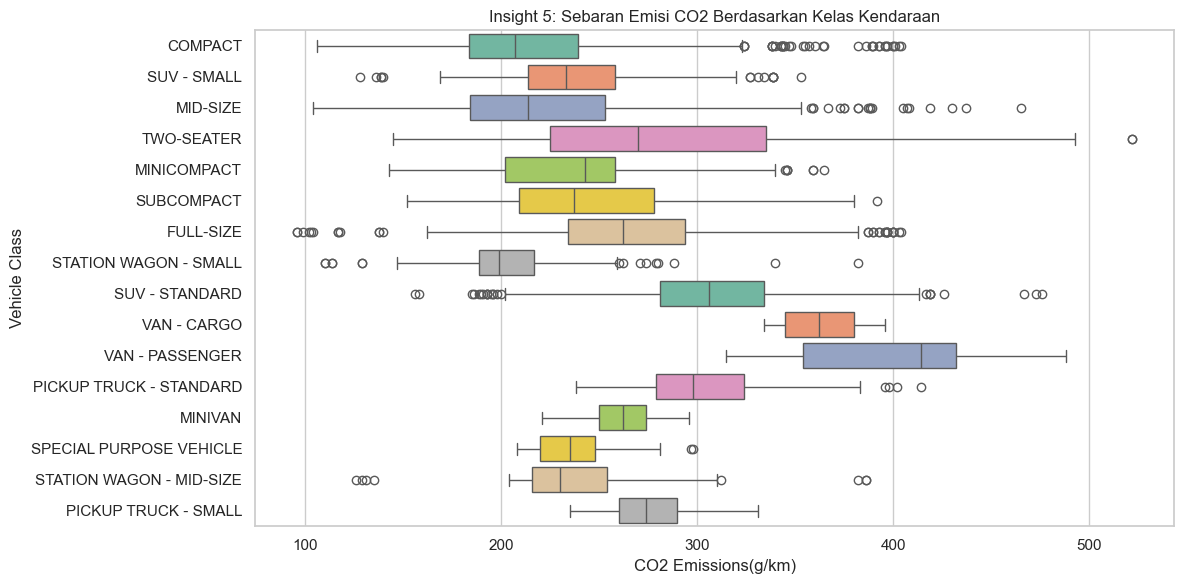

In [8]:
# 4. Bar Plot Fuel Type
plt.figure()
fuel_order = df.groupby('Fuel Type')['CO2 Emissions(g/km)'].mean().sort_values().index
sns.barplot(x='Fuel Type', y='CO2 Emissions(g/km)', data=df, palette='viridis', order=fuel_order, errorbar=None)
plt.title('Insight 4: Rata-rata Emisi CO2 Berdasarkan Jenis Bahan Bakar')
plt.savefig('../reports/insight4_fuel.png')
plt.show()

# 5. Boxplot Vehicle Class
plt.figure(figsize=(12, 6))
sns.boxplot(x='CO2 Emissions(g/km)', y='Vehicle Class', data=df, palette='Set2')
plt.title('Insight 5: Sebaran Emisi CO2 Berdasarkan Kelas Kendaraan')
plt.tight_layout()
plt.savefig('../reports/insight5_boxplot.png')
plt.show()

Feature Engineering & Preprocessing Data

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

# Buang kolom dengan tingkat keunikan terlalu tinggi (High Cardinality)
X = df.drop(columns=['CO2 Emissions(g/km)', 'Model', 'Make'])
y = df['CO2 Emissions(g/km)']

# One-Hot Encoding fitur kategorikal
X_encoded = pd.get_dummies(X, drop_first=True)

# Data Splitting (80:20)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Feature Scaling (StandardScaler) pada kolom numerik asli
raw_numeric_cols = ['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)', 
                    'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[raw_numeric_cols] = scaler.fit_transform(X_train[raw_numeric_cols])
X_test_scaled[raw_numeric_cols] = scaler.transform(X_test[raw_numeric_cols])

# Ekspor Data Bersih untuk modeling berikutnya
os.makedirs('../data/processed', exist_ok=True)
joblib.dump((X_train_scaled, X_test_scaled, y_train, y_test, scaler), '../data/processed/clean_data.pkl')
print("✓ Preprocessing selesai! Data bersih disimpan di 'data/processed/clean_data.pkl'.")

✓ Preprocessing selesai! Data bersih disimpan di 'data/processed/clean_data.pkl'.
